In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/Depression_Severity_NLP'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/plots', exist_ok=True)

print("✅ Google Drive bağlandı!")
print(f"📁 Proje klasörü: {PROJECT_DIR}")

Mounted at /content/drive
✅ Google Drive bağlandı!
📁 Proje klasörü: /content/drive/MyDrive/Depression_Severity_NLP


In [2]:
!pip install transformers==4.40.0 -q
!pip install datasets -q
!pip install accelerate -q

print("✅ Tüm kütüphaneler kuruldu!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ Tüm kütüphaneler kuruldu!


In [4]:
!pip install transformers==4.44.0 -q
!pip install accelerate -q

print("✅ Kurulum tamamlandı! Şimdi Runtime > Restart Runtime yapın!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 97.0 MB/s eta 0:00:00
✅ Kurulum tamamlandı! Şimdi Runtime > Restart Runtime yapın!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings, random, os, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score, accuracy_score)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, EvalPrediction)
from torch.utils.data import Dataset

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU kontrolü
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Cihaz: {device}")
if torch.cuda.is_available():
    print(f"🖥️ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU bulunamadı, CPU kullanılacak (eğitim yavaş olabilir)")

✅ Cihaz: cuda
🖥️ GPU: Tesla T4


In [2]:
from google.colab import files

print("📂 CSV dosyasını yükleyin...")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_csv(fname)

# Temizlik
df.columns = df.columns.str.strip().str.lower()
df = df.dropna(subset=['text', 'label'])
df['text'] = df['text'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip().str.lower()
df['label'] = df['label'].replace('minimum', 'minimal')

print(f"✅ Dataset yüklendi: {df.shape[0]:,} satır")
print(f"\n📊 Sınıf Dağılımı:")
print(df['label'].value_counts())

📂 CSV dosyasını yükleyin...


Saving Depression_Severity_Levels_Dataset.csv to Depression_Severity_Levels_Dataset.csv
✅ Dataset yüklendi: 41,859 satır

📊 Sınıf Dağılımı:
label
severe      11176
mild        10661
minimal     10549
moderate     9473
Name: count, dtype: int64


NameError: name 'PROJECT_DIR' is not defined

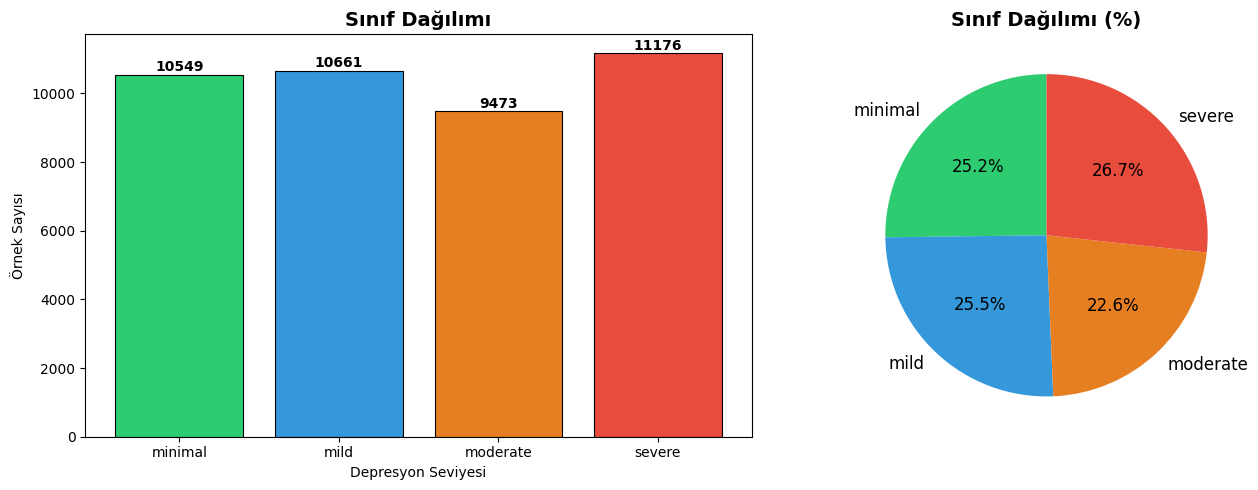

In [3]:
label_order = ['minimal', 'mild', 'moderate', 'severe']
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['label'].value_counts().reindex(label_order)
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Sınıf Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Depresyon Seviyesi')
axes[0].set_ylabel('Örnek Sayısı')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Sınıf Dağılımı (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Metin uzunluğu
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
fig, ax = plt.subplots(figsize=(12, 5))
for i, label in enumerate(label_order):
    subset = df[df['label'] == label]['text_length']
    ax.hist(subset, bins=50, alpha=0.6, label=label, color=colors[i])
ax.set_title('Sınıflara Göre Metin Uzunluğu', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelime Sayısı')
ax.set_ylabel('Frekans')
ax.set_xlim(0, 500)
ax.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/02_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📏 Ortalama metin uzunlukları (kelime):")
print(df.groupby('label')['text_length'].mean().round(1).reindex(label_order))

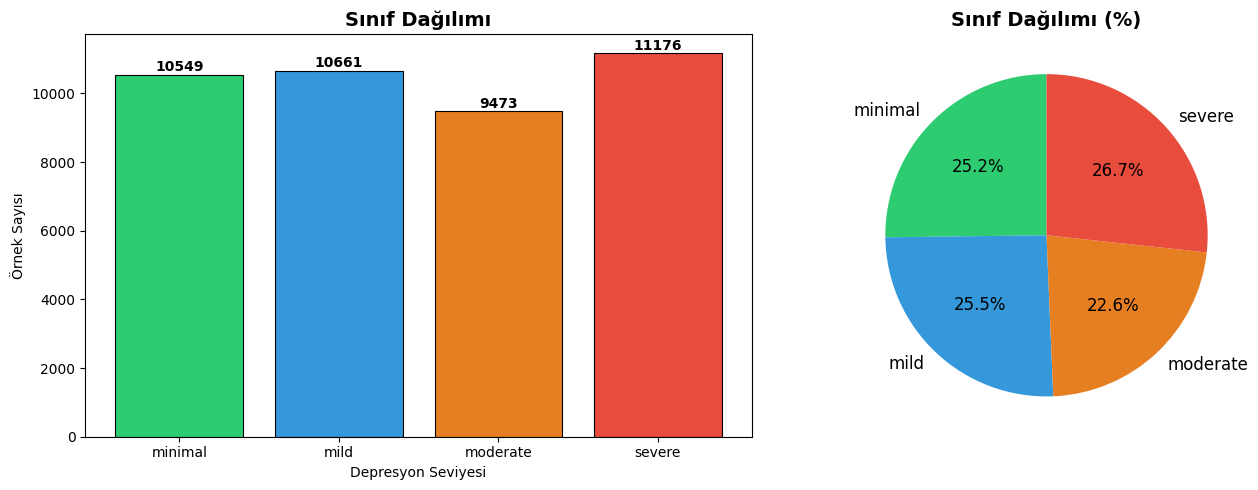

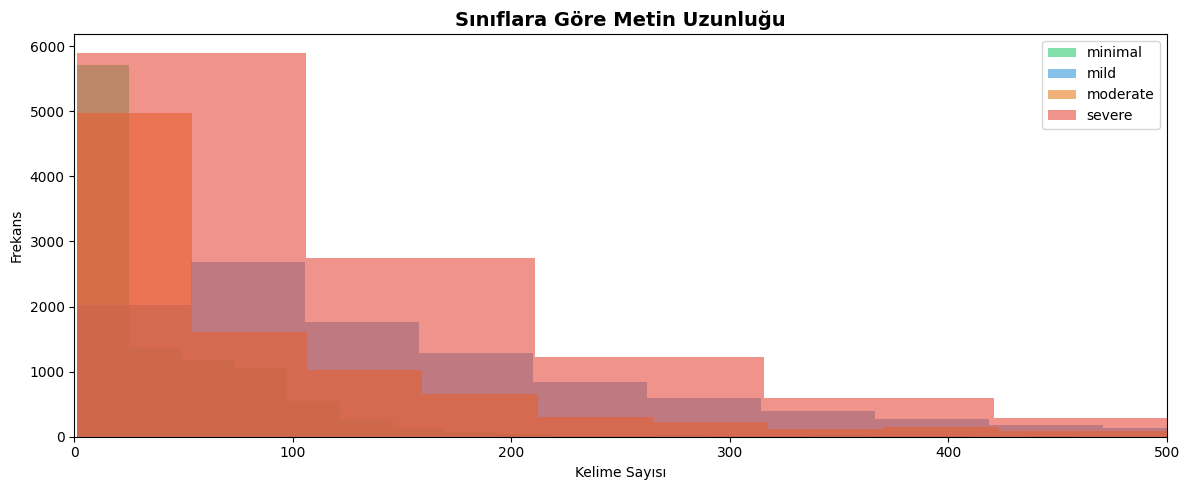


📏 Ortalama metin uzunlukları (kelime):
label
minimal      45.8
mild        177.0
moderate    105.4
severe      155.7
Name: text_length, dtype: float64


In [4]:
PROJECT_DIR = '/content/drive/MyDrive/Depression_Severity_NLP'

label_order = ['minimal', 'mild', 'moderate', 'severe']
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['label'].value_counts().reindex(label_order)
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Sınıf Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Depresyon Seviyesi')
axes[0].set_ylabel('Örnek Sayısı')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Sınıf Dağılımı (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

df['text_length'] = df['text'].apply(lambda x: len(x.split()))
fig, ax = plt.subplots(figsize=(12, 5))
for i, label in enumerate(label_order):
    subset = df[df['label'] == label]['text_length']
    ax.hist(subset, bins=50, alpha=0.6, label=label, color=colors[i])
ax.set_title('Sınıflara Göre Metin Uzunluğu', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelime Sayısı')
ax.set_ylabel('Frekans')
ax.set_xlim(0, 500)
ax.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/02_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📏 Ortalama metin uzunlukları (kelime):")
print(df.groupby('label')['text_length'].mean().round(1).reindex(label_order))

In [5]:
label2id = {'minimal': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
id2label = {0: 'minimal', 1: 'mild', 2: 'moderate', 3: 'severe'}

df['label_id'] = df['label'].map(label2id)

# %70 train / %15 val / %15 test
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label_id'])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label_id'])

# Drive'a kaydet
train_df.to_csv(f'{PROJECT_DIR}/train.csv', index=False)
val_df.to_csv(f'{PROJECT_DIR}/val.csv',   index=False)
test_df.to_csv(f'{PROJECT_DIR}/test.csv',  index=False)

print(f"✅ Veri bölme tamamlandı:")
print(f"   Train : {len(train_df):,}")
print(f"   Val   : {len(val_df):,}")
print(f"   Test  : {len(test_df):,}")
print(f"\n💾 Dosyalar Drive'a kaydedildi.")

✅ Veri bölme tamamlandı:
   Train : 29,301
   Val   : 6,279
   Test  : 6,279

💾 Dosyalar Drive'a kaydedildi.


In [6]:
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("✅ DepressionDataset sınıfı tanımlandı.")

✅ DepressionDataset sınıfı tanımlandı.


In [7]:
def compute_metrics(p: EvalPrediction):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    return {
        'accuracy':  accuracy_score(labels, preds),
        'f1_micro':  f1_score(labels, preds, average='micro'),
        'f1_macro':  f1_score(labels, preds, average='macro'),
        'precision': precision_score(labels, preds, average='micro'),
        'recall':    recall_score(labels, preds, average='micro'),
    }

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_order, yticklabels=label_order, ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix (Sayı)', fontweight='bold')
    axes[0].set_ylabel('Gerçek')
    axes[0].set_xlabel('Tahmin')

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges',
                xticklabels=label_order, yticklabels=label_order, ax=axes[1])
    axes[1].set_title(f'{model_name} — Confusion Matrix (%)', fontweight='bold')
    axes[1].set_ylabel('Gerçek')
    axes[1].set_xlabel('Tahmin')

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/plots/{model_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_training_history(log_history, model_name):
    train_loss, val_loss, val_f1 = [], [], []
    for entry in log_history:
        if 'loss' in entry and 'eval_loss' not in entry:
            train_loss.append(entry['loss'])
        if 'eval_loss' in entry:
            val_loss.append(entry['eval_loss'])
            val_f1.append(entry.get('eval_f1_micro', 0))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if train_loss:
        axes[0].plot(train_loss, label='Train Loss', color='#e74c3c', marker='o', markersize=3)
    if val_loss:
        axes[0].plot(val_loss, label='Val Loss', color='#3498db', marker='s', markersize=5)
    axes[0].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[0].set_xlabel('Adım')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if val_f1:
        axes[1].plot(val_f1, label='Val F1 (micro)', color='#2ecc71', marker='D', markersize=5)
        axes[1].set_title(f'{model_name} — Validation F1', fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('F1 Score')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{PROJECT_DIR}/plots/{model_name}_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

print("✅ Fonksiyonlar hazır.")

✅ Fonksiyonlar hazır.


In [8]:
def train_and_evaluate(model_name, num_epochs=3, batch_size=16, max_len=128, lr=2e-5):
    print(f"\n{'='*60}")
    print(f"🚀 Model: {model_name}")
    print(f"{'='*60}")

    short_name = model_name.split('/')[-1]

    # Tokenizer & Model
    print("📥 Tokenizer ve model yükleniyor...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=4,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    # Dataset
    train_dataset = DepressionDataset(train_df['text'].tolist(), train_df['label_id'].tolist(), tokenizer, max_len)
    val_dataset   = DepressionDataset(val_df['text'].tolist(),   val_df['label_id'].tolist(),   tokenizer, max_len)
    test_dataset  = DepressionDataset(test_df['text'].tolist(),  test_df['label_id'].tolist(),  tokenizer, max_len)

    # Eğitim argümanları
    training_args = TrainingArguments(
        output_dir=f'{PROJECT_DIR}/models/{short_name}',
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        warmup_ratio=0.1,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_f1_micro',
        logging_steps=100,
        fp16=True,
        seed=SEED,
        report_to='none'
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    # Eğit
    print("🏋️ Eğitim başlıyor...")
    trainer.train()

    # Görseller
    plot_training_history(trainer.state.log_history, short_name)

    # Test
    print("\n📊 Test seti değerlendirmesi...")
    test_results = trainer.predict(test_dataset)
    y_pred = np.argmax(test_results.predictions, axis=1)
    y_true = test_df['label_id'].tolist()

    plot_confusion_matrix(y_true, y_pred, short_name)

    print("\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=label_order))

    # Sonuçları kaydet
    results = {
        'model':      model_name,
        'accuracy':   float(accuracy_score(y_true, y_pred)),
        'f1_micro':   float(f1_score(y_true, y_pred, average='micro')),
        'f1_macro':   float(f1_score(y_true, y_pred, average='macro')),
        'precision':  float(precision_score(y_true, y_pred, average='micro')),
        'recall':     float(recall_score(y_true, y_pred, average='micro')),
    }

    with open(f'{PROJECT_DIR}/results/{short_name}_results.json', 'w') as f:
        json.dump(results, f, indent=2)

    print(f"\n💾 Sonuçlar kaydedildi.")
    return results

print("✅ train_and_evaluate() fonksiyonu hazır.")

✅ train_and_evaluate() fonksiyonu hazır.


In [10]:
from huggingface_hub import login

# HuggingFace token'ınızı girin
# Token almak için: https://huggingface.co/settings/tokens
login()


🚀 Model: mental/mental-bert-base-uncased
📥 Tokenizer ve model yükleniyor...


tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🏋️ Eğitim başlıyor...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Precision,Recall
1,0.529400,0.549561,0.728778,0.728778,0.729675,0.728778,0.728778
2,0.459700,0.528590,0.746775,0.746775,0.745696,0.746775,0.746775
3,0.356200,0.588164,0.737697,0.737697,0.737780,0.737697,0.737697


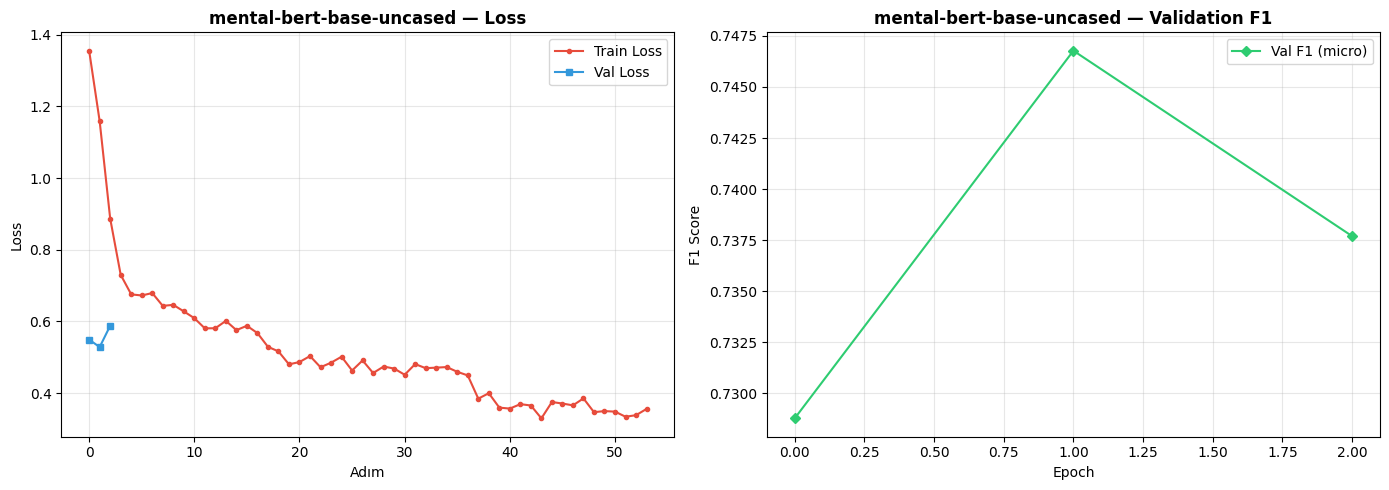


📊 Test seti değerlendirmesi...


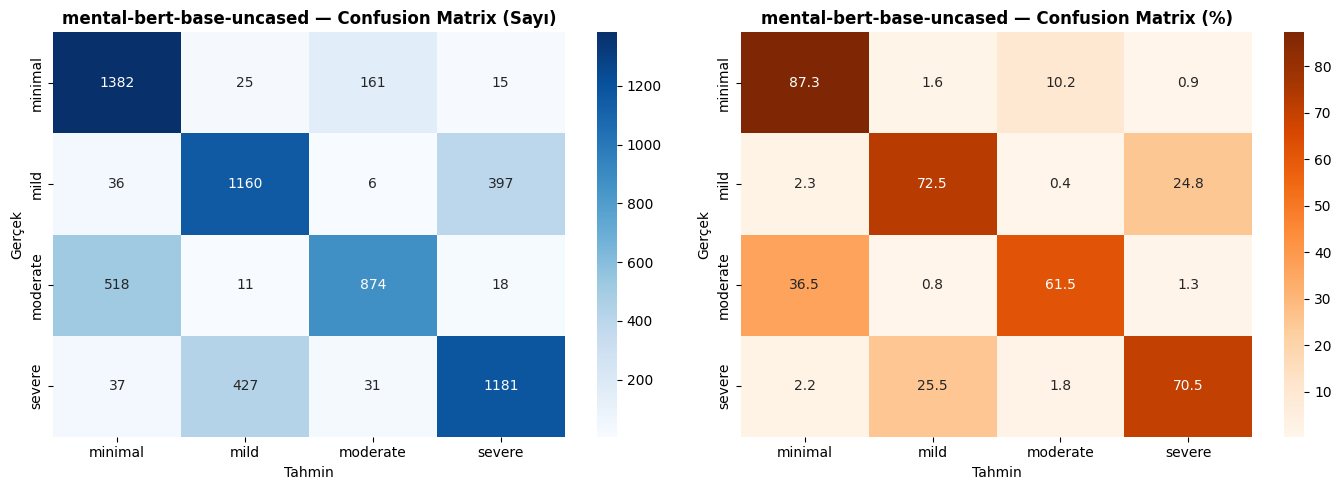


📋 Classification Report:
              precision    recall  f1-score   support

     minimal       0.70      0.87      0.78      1583
        mild       0.71      0.73      0.72      1599
    moderate       0.82      0.62      0.70      1421
      severe       0.73      0.70      0.72      1676

    accuracy                           0.73      6279
   macro avg       0.74      0.73      0.73      6279
weighted avg       0.74      0.73      0.73      6279


💾 Sonuçlar kaydedildi.


In [11]:
results_mentalbert = train_and_evaluate(
    model_name='mental/mental-bert-base-uncased',
    num_epochs=3,
    batch_size=16,
    max_len=128,
    lr=2e-5
)


🚀 Model: roberta-base
📥 Tokenizer ve model yükleniyor...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🏋️ Eğitim başlıyor...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Precision,Recall
1,0.566000,0.578098,0.719860,0.719860,0.717436,0.719860,0.719860
2,0.489000,0.539383,0.747731,0.747731,0.745810,0.747731,0.747731
3,0.423000,0.564206,0.748208,0.748208,0.746894,0.748208,0.748208


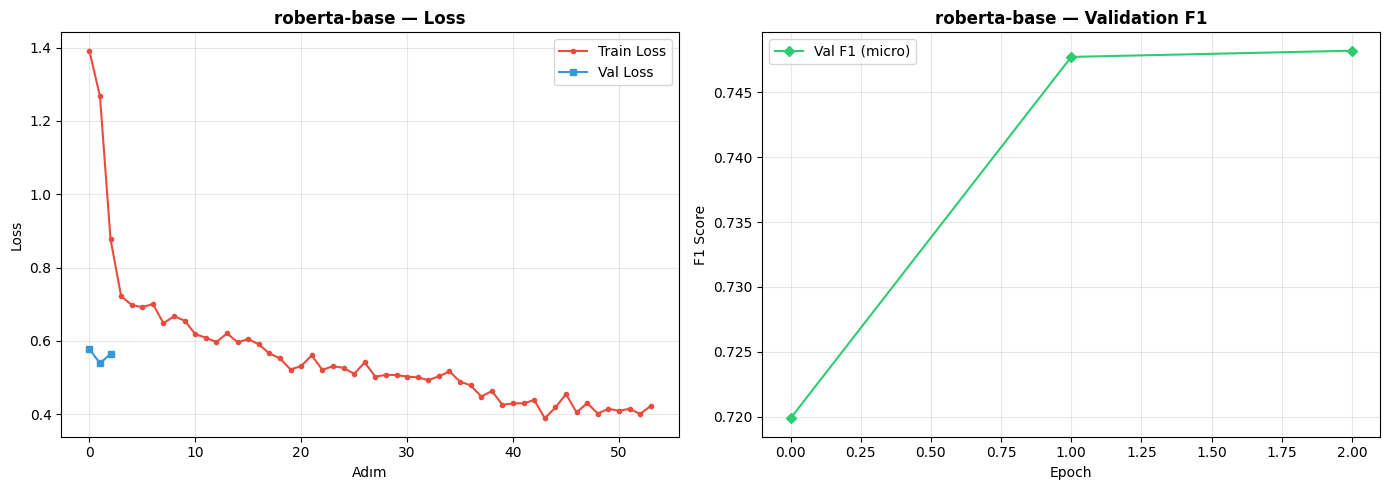


📊 Test seti değerlendirmesi...


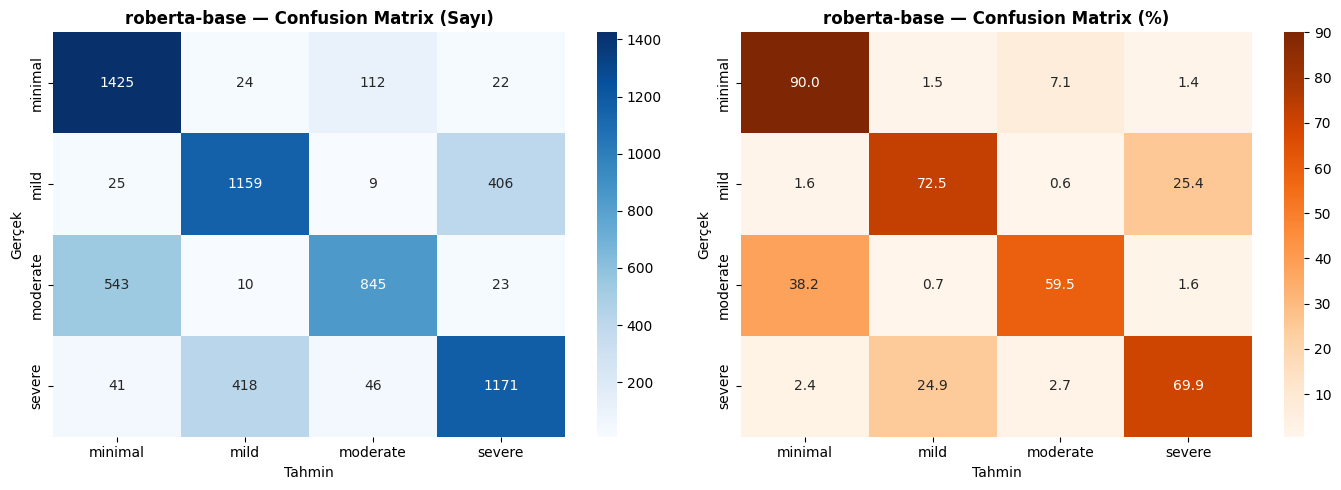


📋 Classification Report:
              precision    recall  f1-score   support

     minimal       0.70      0.90      0.79      1583
        mild       0.72      0.72      0.72      1599
    moderate       0.83      0.59      0.69      1421
      severe       0.72      0.70      0.71      1676

    accuracy                           0.73      6279
   macro avg       0.74      0.73      0.73      6279
weighted avg       0.74      0.73      0.73      6279


💾 Sonuçlar kaydedildi.


In [12]:
results_roberta = train_and_evaluate(
    model_name='roberta-base',
    num_epochs=3,
    batch_size=16,
    max_len=128,
    lr=2e-5
)


🚀 Model: mental/mental-roberta-base
📥 Tokenizer ve model yükleniyor...


tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🏋️ Eğitim başlıyor...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Precision,Recall
1,0.541300,0.567548,0.727027,0.727027,0.728030,0.727027,0.727027


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Precision,Recall
1,0.541300,0.567548,0.727027,0.727027,0.728030,0.727027,0.727027
2,0.451800,0.536541,0.749323,0.749323,0.747689,0.749323,0.749323
3,0.401600,0.581353,0.750756,0.750756,0.749583,0.750756,0.750756


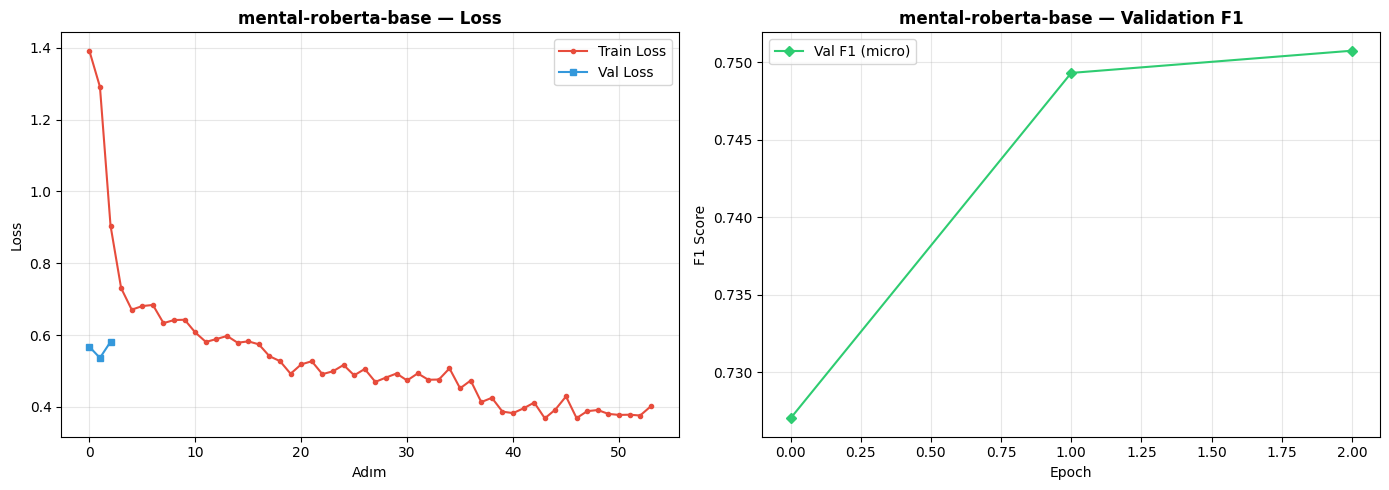


📊 Test seti değerlendirmesi...


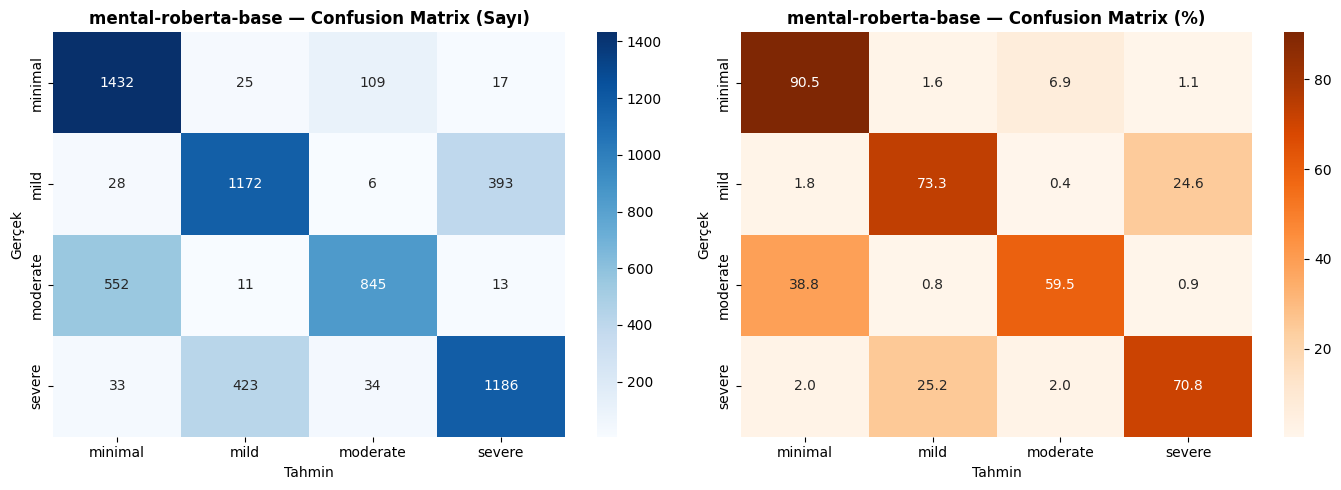


📋 Classification Report:
              precision    recall  f1-score   support

     minimal       0.70      0.90      0.79      1583
        mild       0.72      0.73      0.73      1599
    moderate       0.85      0.59      0.70      1421
      severe       0.74      0.71      0.72      1676

    accuracy                           0.74      6279
   macro avg       0.75      0.73      0.73      6279
weighted avg       0.75      0.74      0.73      6279


💾 Sonuçlar kaydedildi.


In [14]:
# Önce mental/mental-roberta-base'i dene
# Erişim yoksa alternatif kullan

try:
    results_mental_roberta = train_and_evaluate(
        model_name='mental/mental-roberta-base',
        num_epochs=3,
        batch_size=16,
        max_len=128,
        lr=2e-5
    )
except Exception as e:
    print(f"⚠️ mental-roberta-base erişilemedi: {e}")
    print("🔄 Alternatif model deneniyor: vinai/bertweet-base")
    results_mental_roberta = train_and_evaluate(
        model_name='vinai/bertweet-base',
        num_epochs=3,
        batch_size=16,
        max_len=128,
        lr=2e-5
    )

📊 Model Karşılaştırma Tablosu:
               accuracy  f1_micro  f1_macro  precision  recall
MentalBERT       0.7321    0.7321    0.7293     0.7321  0.7321
RoBERTa          0.7326    0.7326    0.7287     0.7326  0.7326
MentalRoBERTa    0.7382    0.7382    0.7342     0.7382  0.7382


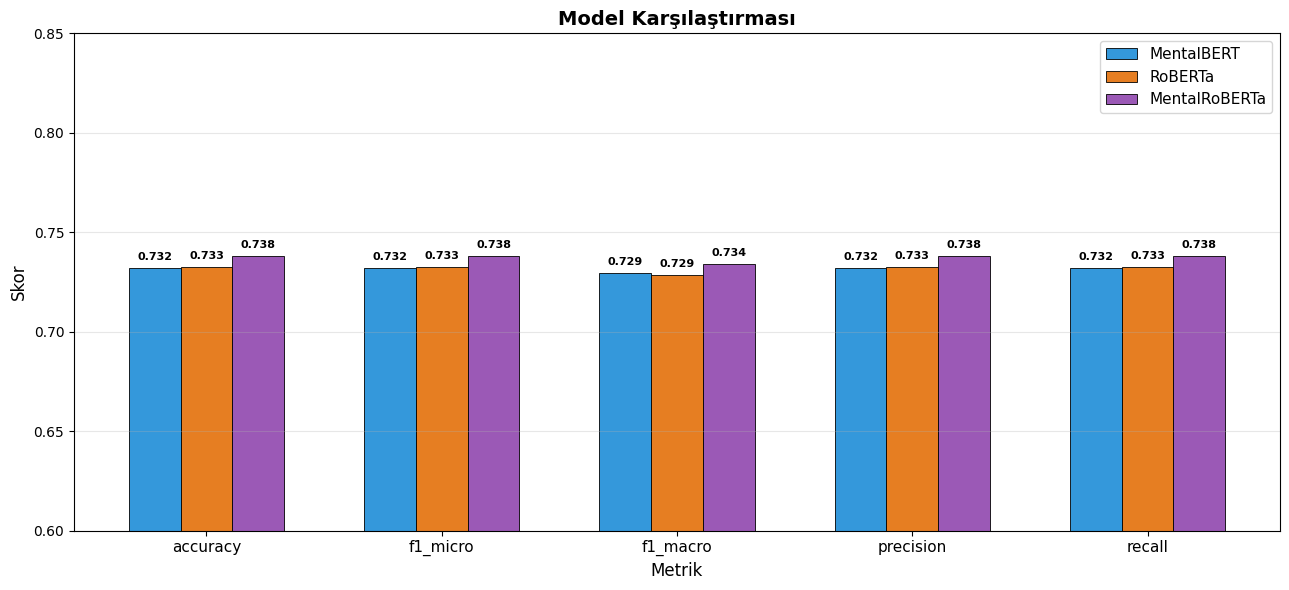

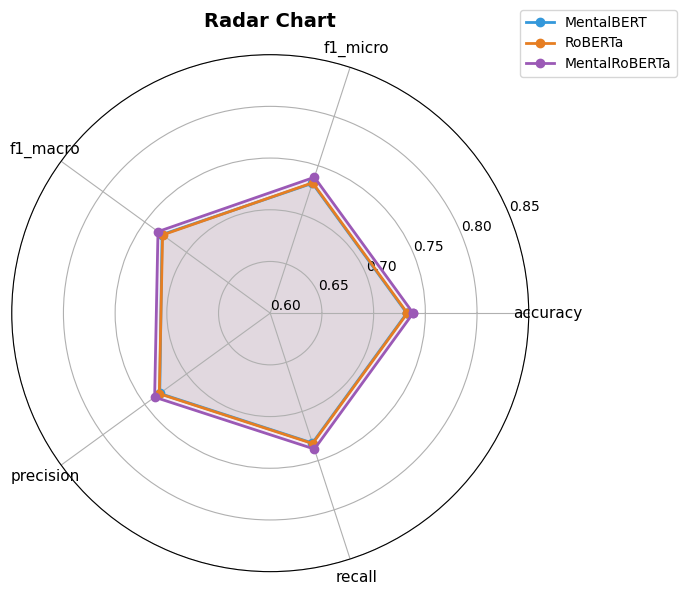

In [15]:
all_results = {
    'MentalBERT':     results_mentalbert,
    'RoBERTa':        results_roberta,
    'MentalRoBERTa':  results_mental_roberta,
}

# Karşılaştırma tablosu
metrics = ['accuracy', 'f1_micro', 'f1_macro', 'precision', 'recall']
comparison = pd.DataFrame({
    name: {m: res[m] for m in metrics}
    for name, res in all_results.items()
}).T.round(4)

print("📊 Model Karşılaştırma Tablosu:")
print(comparison.to_string())
comparison.to_csv(f'{PROJECT_DIR}/results/comparison_table.csv')

# ---- Grouped Bar Chart ----
colors_models = ['#3498db', '#e67e22', '#9b59b6']
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(metrics))
width = 0.22

for i, (name, color) in enumerate(zip(comparison.index, colors_models)):
    bars = ax.bar(x + i*width, comparison.loc[name, metrics],
                  width, label=name, color=color, edgecolor='black', linewidth=0.6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Model Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.60, 0.85)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Radar Chart ----
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

for name, color in zip(comparison.index, colors_models):
    values = comparison.loc[name, metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=11)
ax.set_ylim(0.6, 0.85)
ax.set_title('Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Makale Benchmark Karşılaştırması:
               precision  recall  f1_micro
DepressionNet      0.610   0.590     0.600
DEPTWEET           0.620   0.610     0.610
SVM+LBFs           0.510   0.560     0.520
RF+LBFs            0.590   0.540     0.560
MLP+LBFs           0.560   0.540     0.560
HelaDepDet         0.680   0.650     0.660
MentalBERT         0.732   0.732     0.732
RoBERTa            0.733   0.733     0.733
MentalRoBERTa      0.738   0.738     0.738


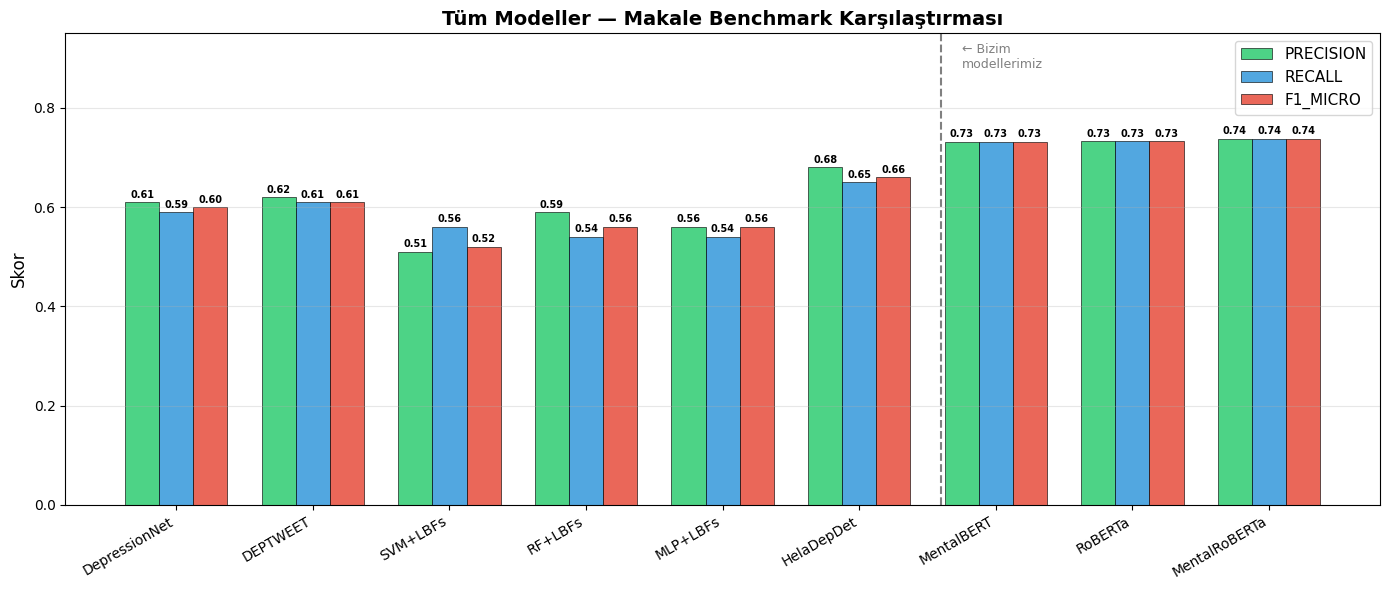

In [17]:
# Makaledeki HelaDepDet sonuçları
paper_results = {
    'DepressionNet': {'precision': 0.61, 'recall': 0.59, 'f1_micro': 0.60},
    'DEPTWEET':      {'precision': 0.62, 'recall': 0.61, 'f1_micro': 0.61},
    'SVM+LBFs':      {'precision': 0.51, 'recall': 0.56, 'f1_micro': 0.52},
    'RF+LBFs':       {'precision': 0.59, 'recall': 0.54, 'f1_micro': 0.56},
    'MLP+LBFs':      {'precision': 0.56, 'recall': 0.54, 'f1_micro': 0.56},
    'HelaDepDet':    {'precision': 0.68, 'recall': 0.65, 'f1_micro': 0.66},
    'MentalBERT':    {'precision': results_mentalbert['precision'],   'recall': results_mentalbert['recall'],   'f1_micro': results_mentalbert['f1_micro']},
    'RoBERTa':       {'precision': results_roberta['precision'],      'recall': results_roberta['recall'],      'f1_micro': results_roberta['f1_micro']},
    'MentalRoBERTa': {'precision': results_mental_roberta['precision'],'recall': results_mental_roberta['recall'],'f1_micro': results_mental_roberta['f1_micro']},
}

bench_df = pd.DataFrame(paper_results).T.round(3)
print("📊 Makale Benchmark Karşılaştırması:")
print(bench_df.to_string())
bench_df.to_csv(f'{PROJECT_DIR}/results/benchmark_comparison.csv')

# Görsel
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(bench_df))
w = 0.25
bar_colors = ['#2ecc71', '#3498db', '#e74c3c']
bench_metrics = ['precision', 'recall', 'f1_micro']

for i, (metric, color) in enumerate(zip(bench_metrics, bar_colors)):
    bars = ax.bar(x + i*w, bench_df[metric], w, label=metric.upper(),
                  color=color, edgecolor='black', linewidth=0.5, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + w)
ax.set_xticklabels(bench_df.index, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Tüm Modeller — Makale Benchmark Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.95)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axvline(x=5.85, color='gray', linestyle='--', linewidth=1.5)
ax.text(6.0, 0.88, '← Bizim\nmodellerimiz', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print("="*60)
print("🏆 DENEY SONUÇLARI ÖZETİ")
print("="*60)

summary = {
    'MentalBERT':    results_mentalbert,
    'RoBERTa':       results_roberta,
    'MentalRoBERTa': results_mental_roberta,
}

for name, res in summary.items():
    print(f"\n📌 {name}")
    print(f"   Accuracy  : {res['accuracy']:.4f}")
    print(f"   F1 Micro  : {res['f1_micro']:.4f}")
    print(f"   F1 Macro  : {res['f1_macro']:.4f}")
    print(f"   Precision : {res['precision']:.4f}")
    print(f"   Recall    : {res['recall']:.4f}")

best_model = max(summary, key=lambda x: summary[x]['f1_micro'])
print(f"\n🥇 En iyi model: {best_model} (F1 Micro: {summary[best_model]['f1_micro']:.4f})")
print(f"📈 HelaDepDet'e göre iyileşme: +{(summary[best_model]['f1_micro'] - 0.66):.4f}")

# Tüm sonuçları tek JSON'a kaydet
with open(f'{PROJECT_DIR}/results/final_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✅ Tüm sonuçlar kaydedildi: {PROJECT_DIR}/results/")
print(f"✅ Tüm görseller kaydedildi: {PROJECT_DIR}/plots/")

🏆 DENEY SONUÇLARI ÖZETİ

📌 MentalBERT
   Accuracy  : 0.7321
   F1 Micro  : 0.7321
   F1 Macro  : 0.7293
   Precision : 0.7321
   Recall    : 0.7321

📌 RoBERTa
   Accuracy  : 0.7326
   F1 Micro  : 0.7326
   F1 Macro  : 0.7287
   Precision : 0.7326
   Recall    : 0.7326

📌 MentalRoBERTa
   Accuracy  : 0.7382
   F1 Micro  : 0.7382
   F1 Macro  : 0.7342
   Precision : 0.7382
   Recall    : 0.7382

🥇 En iyi model: MentalRoBERTa (F1 Micro: 0.7382)
📈 HelaDepDet'e göre iyileşme: +0.0782

✅ Tüm sonuçlar kaydedildi: /content/drive/MyDrive/Depression_Severity_NLP/results/
✅ Tüm görseller kaydedildi: /content/drive/MyDrive/Depression_Severity_NLP/plots/



🚀 Model: mental/mental-roberta-base
📥 Tokenizer ve model yükleniyor...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🏋️ Eğitim başlıyor...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Precision,Recall
1,0.564500,0.561461,0.739608,0.739608,0.737132,0.739608,0.739608
2,0.510800,0.537201,0.760949,0.760949,0.758357,0.760949,0.760949


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Precision,Recall
1,0.564500,0.561461,0.739608,0.739608,0.737132,0.739608,0.739608
2,0.510800,0.537201,0.760949,0.760949,0.758357,0.760949,0.760949
3,0.390300,0.673594,0.757923,0.757923,0.757000,0.757923,0.757923
4,0.397200,0.797700,0.753305,0.753305,0.752510,0.753305,0.753305
5,0.275500,0.926085,0.757605,0.757605,0.755718,0.757605,0.757605


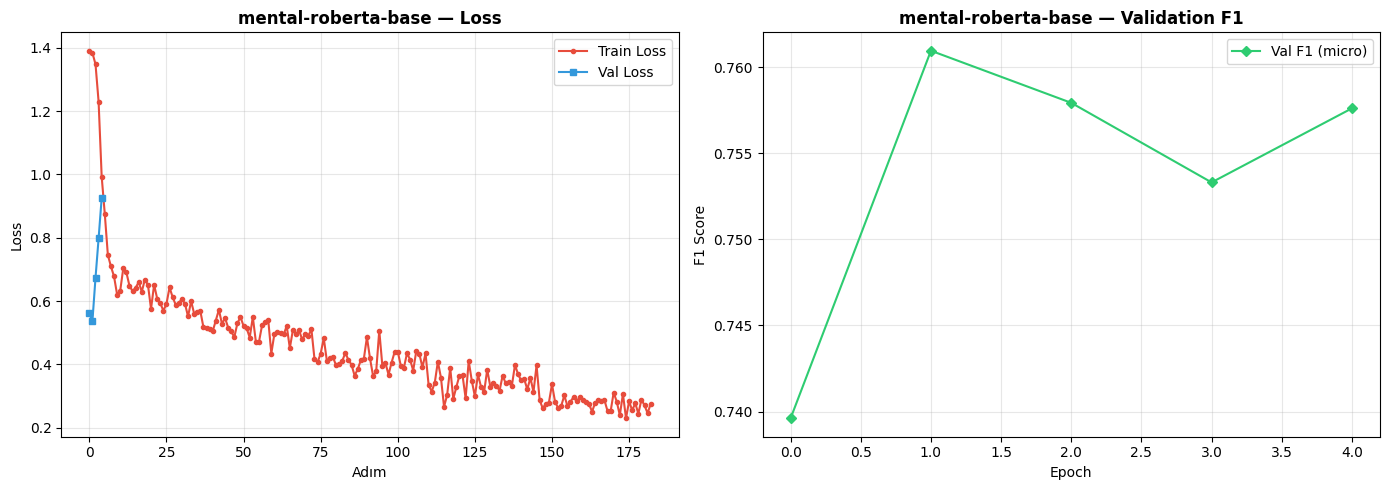


📊 Test seti değerlendirmesi...


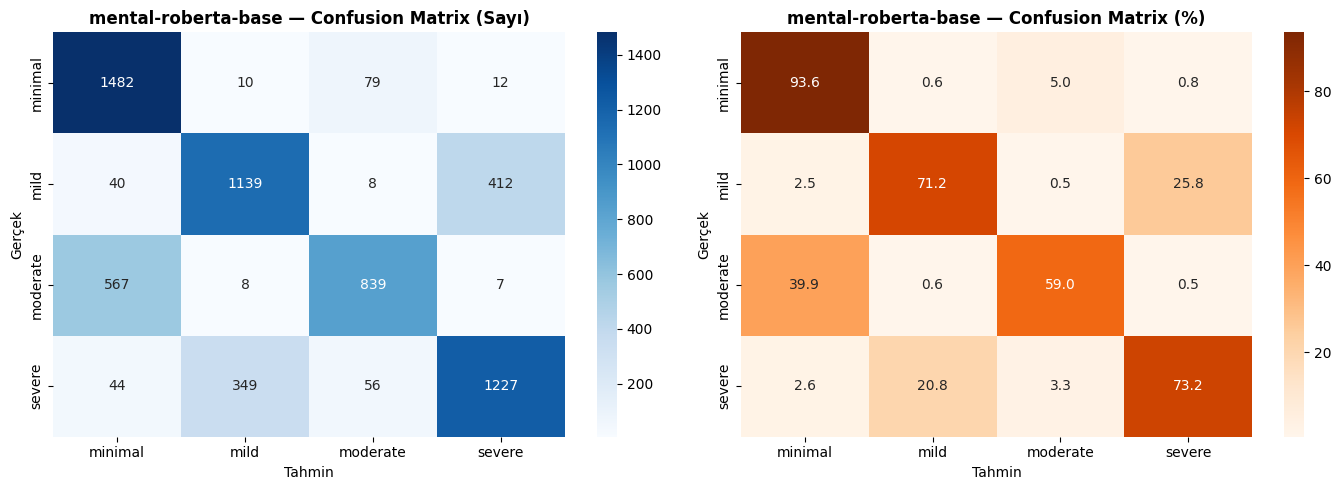


📋 Classification Report:
              precision    recall  f1-score   support

     minimal       0.69      0.94      0.80      1583
        mild       0.76      0.71      0.73      1599
    moderate       0.85      0.59      0.70      1421
      severe       0.74      0.73      0.74      1676

    accuracy                           0.75      6279
   macro avg       0.76      0.74      0.74      6279
weighted avg       0.76      0.75      0.74      6279


💾 Sonuçlar kaydedildi.


In [19]:
results_mental_roberta_v2 = train_and_evaluate(
    model_name='mental/mental-roberta-base',
    num_epochs=5,
    batch_size=8,
    max_len=256,
    lr=2e-5
)

In [20]:
all_results_final = {
    'MentalBERT (128tok, 3ep)':      results_mentalbert,
    'RoBERTa (128tok, 3ep)':         results_roberta,
    'MentalRoBERTa (128tok, 3ep)':   results_mental_roberta,
    'MentalRoBERTa (256tok, 5ep)':   results_mental_roberta_v2,
}

metrics = ['accuracy', 'f1_micro', 'f1_macro', 'precision', 'recall']
comparison = pd.DataFrame({
    name: {m: res[m] for m in metrics}
    for name, res in all_results_final.items()
}).T.round(4)

print("📊 4 Modelin Test Performansı:")
print(comparison.to_string())
comparison.to_csv(f'{PROJECT_DIR}/results/final_4model_comparison.csv')

📊 4 Modelin Test Performansı:
                             accuracy  f1_micro  f1_macro  precision  recall
MentalBERT (128tok, 3ep)       0.7321    0.7321    0.7293     0.7321  0.7321
RoBERTa (128tok, 3ep)          0.7326    0.7326    0.7287     0.7326  0.7326
MentalRoBERTa (128tok, 3ep)    0.7382    0.7382    0.7342     0.7382  0.7382
MentalRoBERTa (256tok, 5ep)    0.7465    0.7465    0.7414     0.7465  0.7465


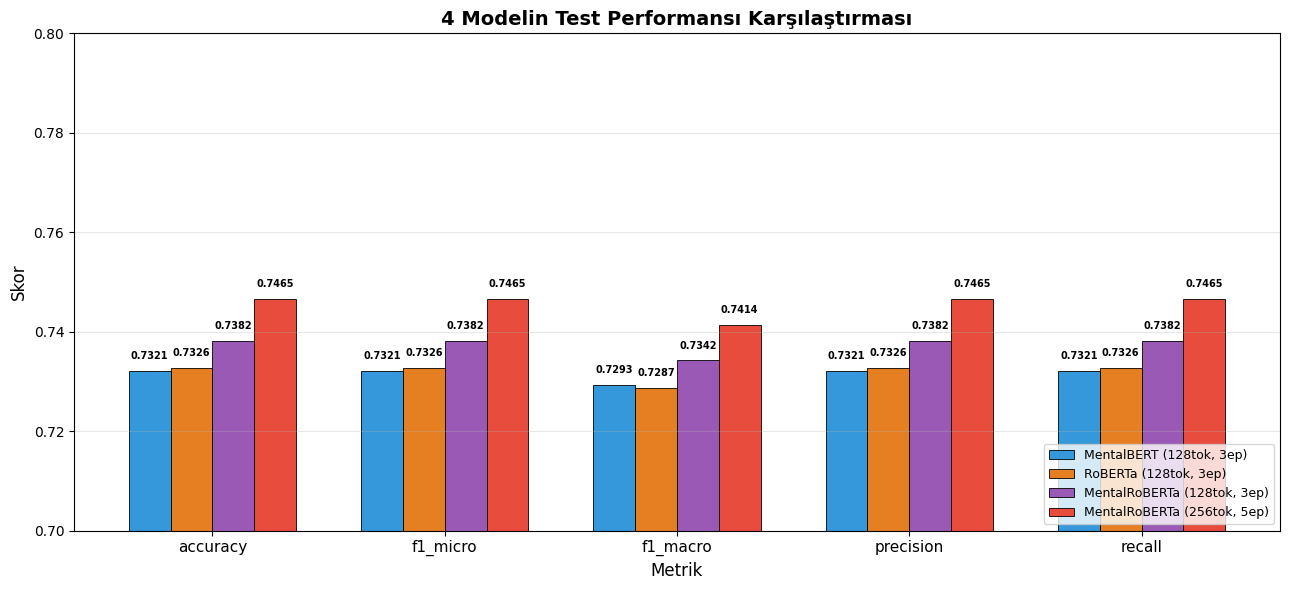


🥇 En iyi model: MentalRoBERTa (256tok, 5ep)
   F1 Micro : 0.7465
   HelaDepDet'e göre iyileşme: +0.0865


In [21]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(metrics))
width = 0.18
colors_4 = ['#3498db', '#e67e22', '#9b59b6', '#e74c3c']

for i, (name, color) in enumerate(zip(comparison.index, colors_4)):
    bars = ax.bar(x + i*width, comparison.loc[name, metrics],
                  width, label=name, color=color, edgecolor='black', linewidth=0.6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('4 Modelin Test Performansı Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.70, 0.80)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/final_4model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🥇 En iyi model: MentalRoBERTa (256tok, 5ep)")
print(f"   F1 Micro : 0.7465")
print(f"   HelaDepDet'e göre iyileşme: +{0.7465 - 0.66:.4f}")

📊 3 Modelin Test Performansı:
                             accuracy  f1_micro  f1_macro  precision  recall
MentalBERT (128tok, 3ep)       0.7321    0.7321    0.7293     0.7321  0.7321
RoBERTa (128tok, 3ep)          0.7326    0.7326    0.7287     0.7326  0.7326
MentalRoBERTa (256tok, 5ep)    0.7465    0.7465    0.7414     0.7465  0.7465


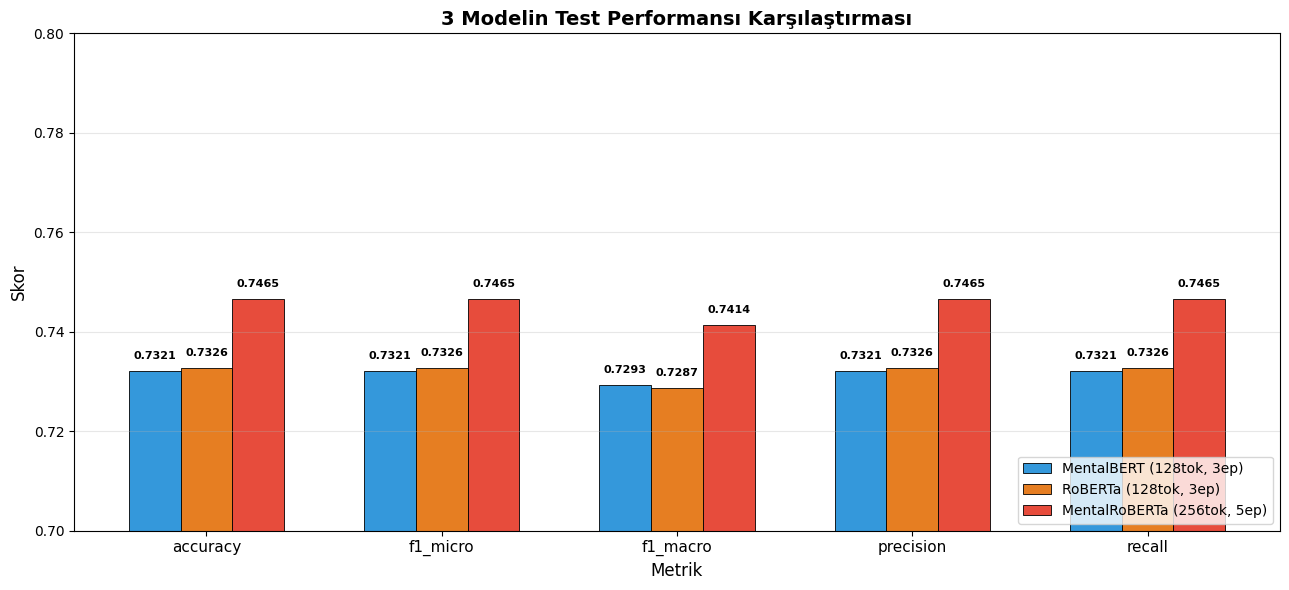

In [22]:
selected_results = {
    'MentalBERT (128tok, 3ep)':    results_mentalbert,
    'RoBERTa (128tok, 3ep)':       results_roberta,
    'MentalRoBERTa (256tok, 5ep)': results_mental_roberta_v2,
}

metrics = ['accuracy', 'f1_micro', 'f1_macro', 'precision', 'recall']
comparison3 = pd.DataFrame({
    name: {m: res[m] for m in metrics}
    for name, res in selected_results.items()
}).T.round(4)

print("📊 3 Modelin Test Performansı:")
print(comparison3.to_string())

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(metrics))
width = 0.22
colors_3 = ['#3498db', '#e67e22', '#e74c3c']

for i, (name, color) in enumerate(zip(comparison3.index, colors_3)):
    bars = ax.bar(x + i*width, comparison3.loc[name, metrics],
                  width, label=name, color=color, edgecolor='black', linewidth=0.6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('3 Modelin Test Performansı Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.70, 0.80)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/final_3model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()